# Predicting Taxi trip Fare based on various factors

## Regression Task

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

np.random.seed(42)

## Get the data

In [2]:
import kaggle

# Download dataset to current folder
kaggle.api.dataset_download_files('denkuznetz/taxi-price-prediction', path='.', unzip=True)
print("Dataset downloaded and extracted to current folder.")

Dataset URL: https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction
Dataset downloaded and extracted to current folder.


In [3]:
taxi_prices = pd.read_csv("taxi_trip_pricing.csv")
taxi_prices.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


## Take a quick look at data

In [4]:
taxi_prices.shape

(1000, 11)

In [5]:
# know the attributes
taxi_prices.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='str')

### Attributes
- **Trip_Distance_km:** The distance of the trip in kilometers.
- **Time_of_Day:** The time when the trip started (morning, afternoon, evening, night).
- **Day_of_Week:** The day of the week the trip took place (Monday to Sunday).
- **Passenger_Count:** The number of passengers on the trip.
- **Traffic_Conditions:** The traffic situation during the trip (light, medium, heavy).
- **Weather:** The weather conditions during the trip (clear, rain, snow).
- **Base_Fare:** The fixed starting fare for the trip.
- **Per_Km_Rate:** The cost charged per kilometer traveled.
- **Per_Minute_Rate:** The cost charged per minute of travel.
- **Trip_Duration_Minutes:** The total duration of the trip in minutes.
- **Trip_Price (target):** The final fare amount for the trip in USD.

In [6]:
taxi_prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    str    
 2   Day_of_Week            950 non-null    str    
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    str    
 5   Weather                950 non-null    str    
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 108.5 KB


In [7]:
taxi_prices.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [8]:
taxi_prices.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [9]:
taxi_prices.duplicated().sum()

np.int64(0)

## Discovering & Visualizing Data

### Visualize Data

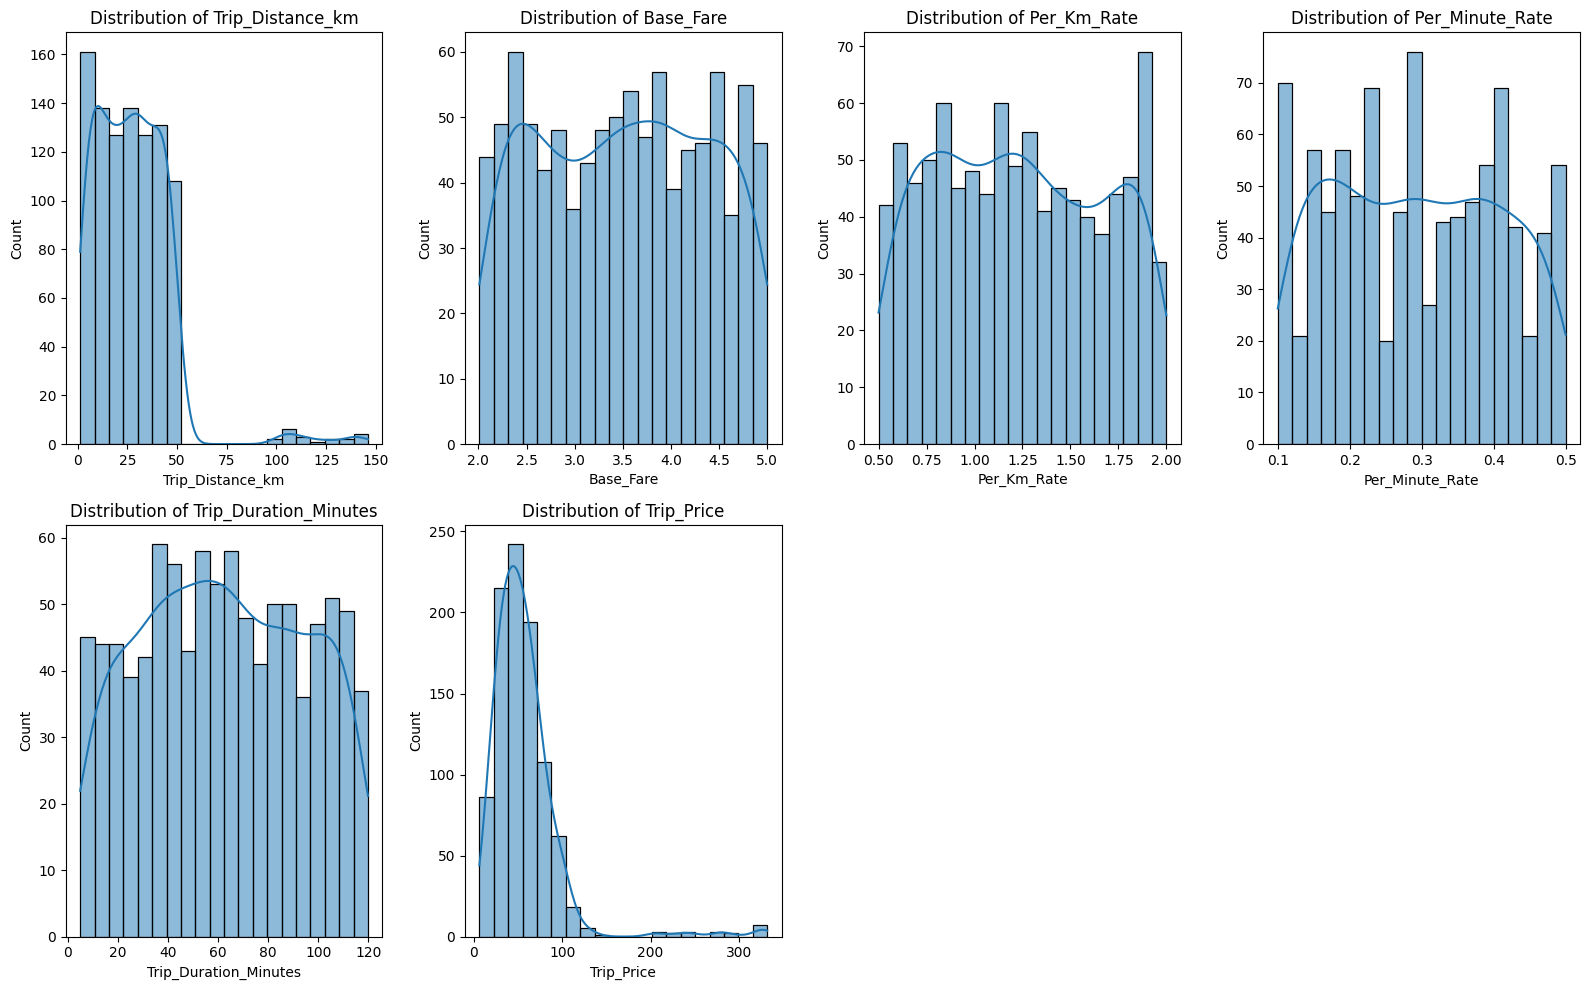

In [10]:
# Distribution of numerical features
numerical_features = [
    'Trip_Distance_km',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes',
    'Trip_Price'
]

plt.figure(figsize=(16, 10))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 4, i)
    
    sns.histplot(
        taxi_prices[feature],
        bins=20,
        kde=True
    )
    
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

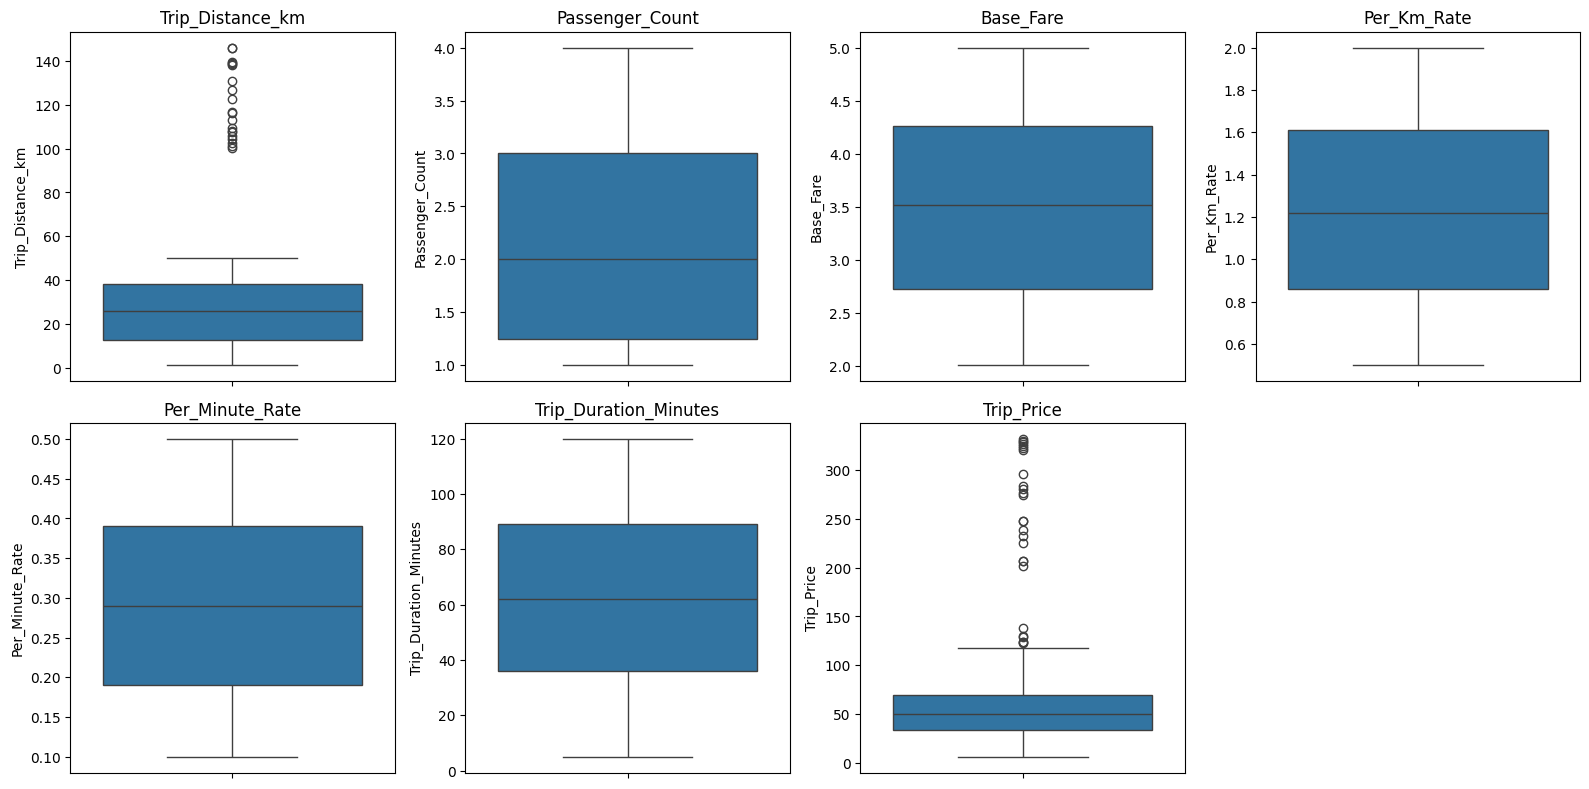

In [11]:
# Boxplots of numerical features
numerical_features = [
    'Trip_Distance_km',
    'Passenger_Count',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes',
    'Trip_Price'
]

plt.figure(figsize=(16, 8))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=taxi_prices[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

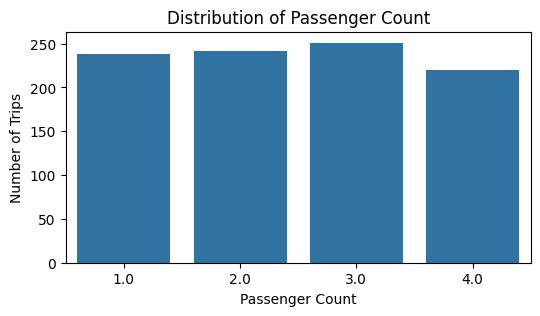

In [12]:
# Distribution of Passenger Count
plt.figure(figsize=(6, 3))

sns.countplot(
    data=taxi_prices,
    x='Passenger_Count'
)

plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Number of Trips')
plt.show()

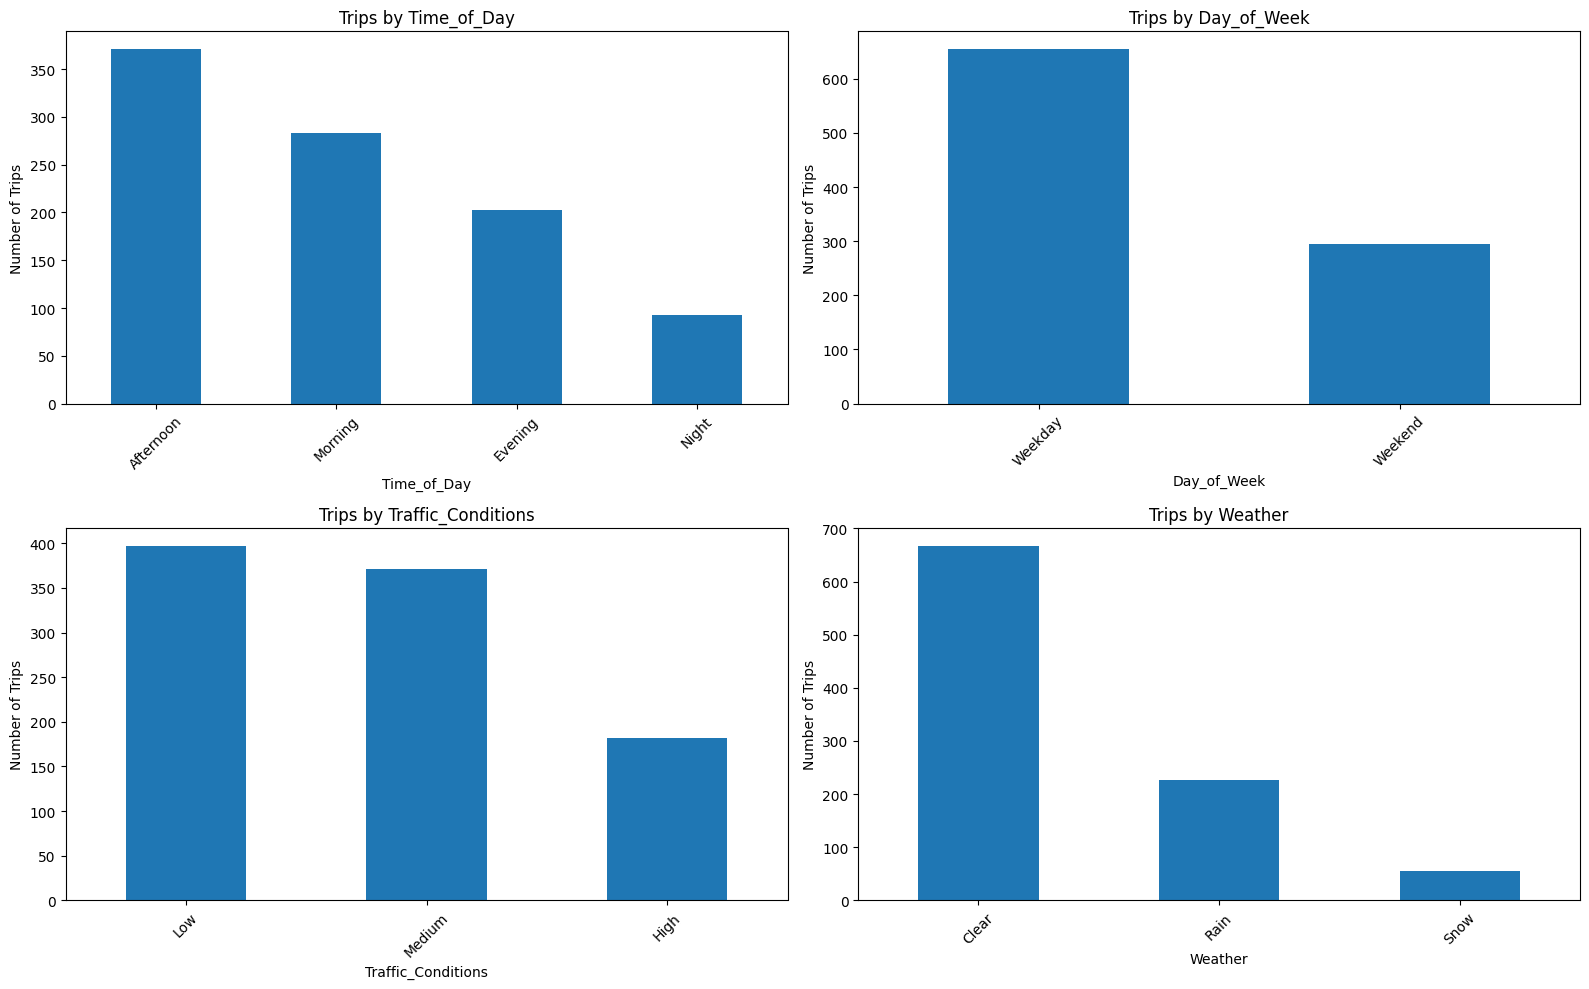

In [13]:
# Distribution of categorical features
categorical_features = [
    'Time_of_Day',
    'Day_of_Week',
    'Traffic_Conditions',
    'Weather'
]

plt.figure(figsize=(16, 10))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    
    taxi_prices[feature].value_counts().plot(kind='bar')
    
    plt.title(f'Trips by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Trips')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

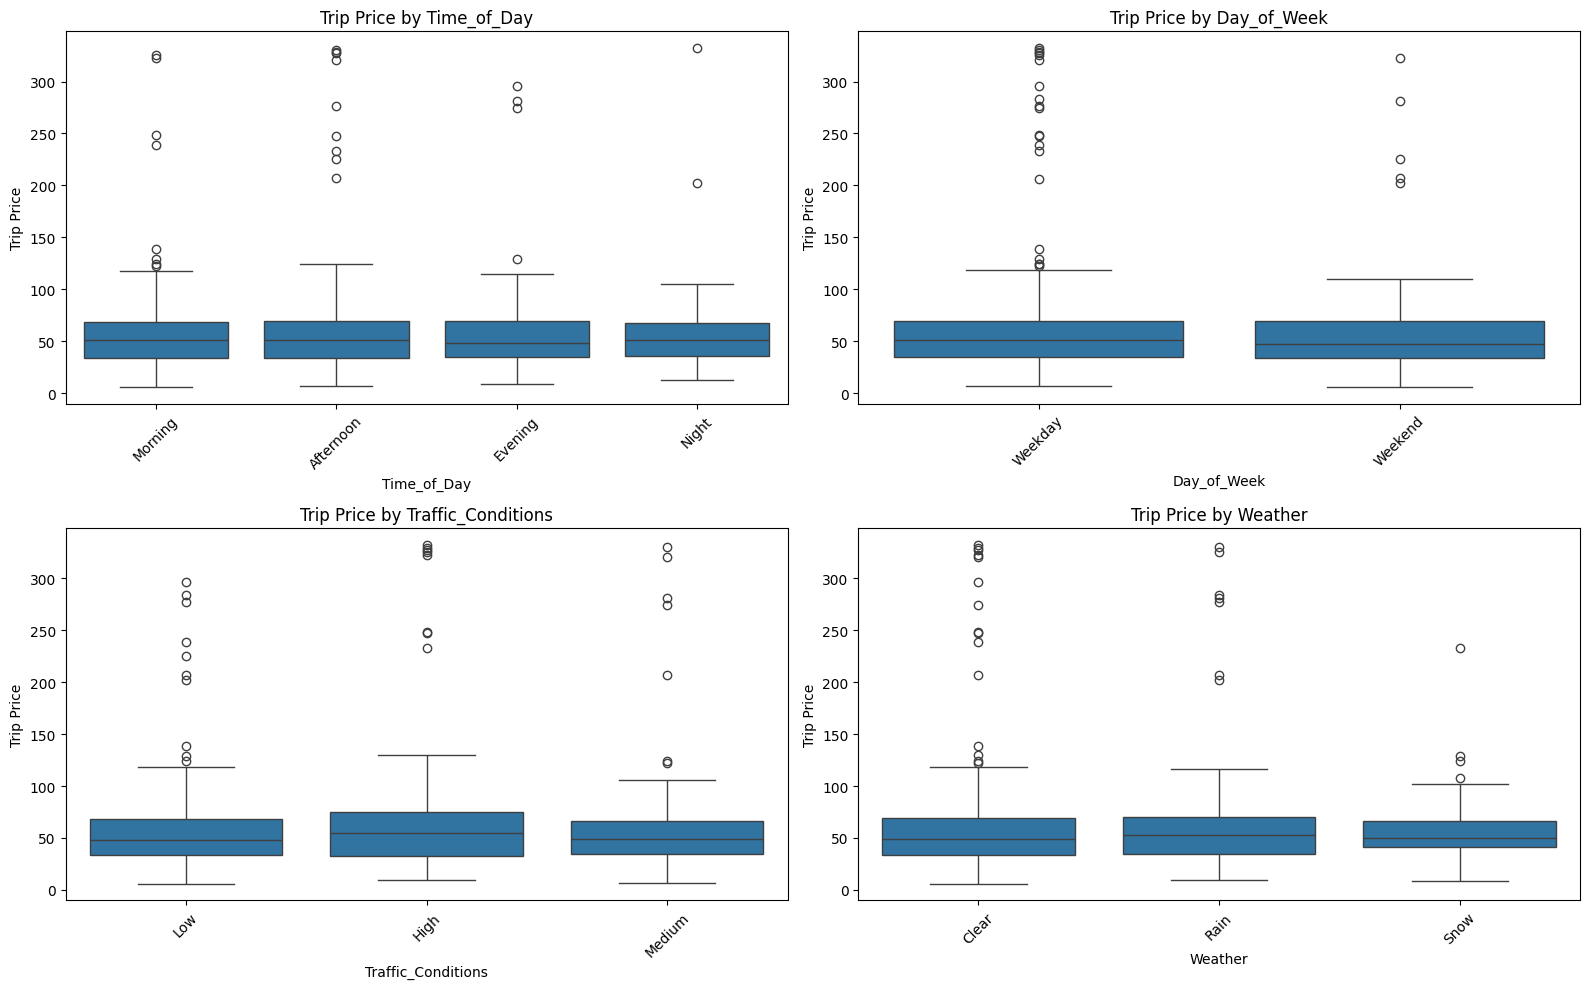

In [14]:
# Trip Price vs categorical features
categorical_features = [
    'Time_of_Day',
    'Day_of_Week',
    'Traffic_Conditions',
    'Weather'
]

plt.figure(figsize=(16, 10))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    
    sns.boxplot(
        data=taxi_prices,
        x=feature,
        y='Trip_Price'
    )
    
    plt.title(f'Trip Price by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Trip Price')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

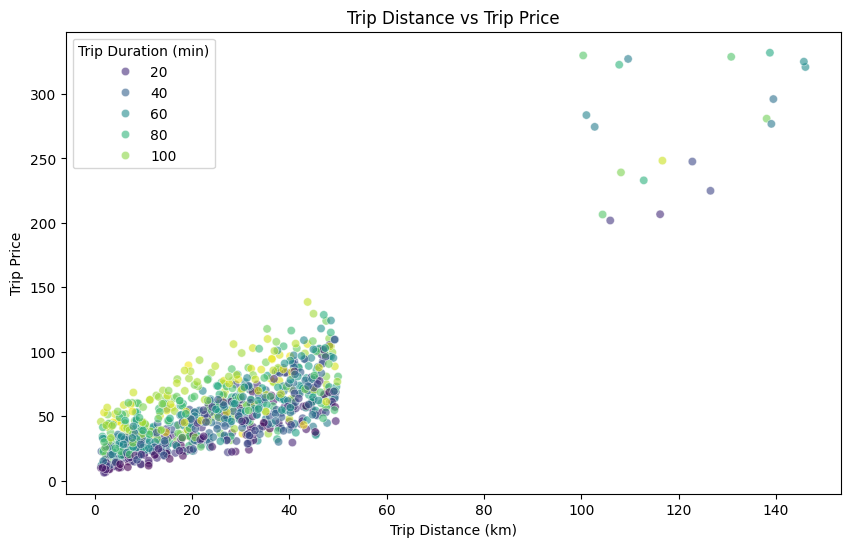

In [15]:
# Trip Distance vs Trip Price
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=taxi_prices,
    x='Trip_Distance_km',
    y='Trip_Price',
    hue='Trip_Duration_Minutes',
    palette='viridis',
    alpha=0.6
)

plt.title('Trip Distance vs Trip Price')
plt.xlabel('Trip Distance (km)')
plt.ylabel('Trip Price')
plt.legend(title='Trip Duration (min)')
plt.show()

## Look for correlations

In [16]:
# Correlation matrix
correlation_features = [
    'Trip_Distance_km',
    'Passenger_Count',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes',
    'Trip_Price'
]

correlation_matrix = taxi_prices[correlation_features].corr()

correlation_matrix

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000000,-0.048397,0.032218,-0.017041,-0.025902,-0.022102,0.849123
Passenger_Count,-0.048397,1.000000,0.022932,0.030213,0.034068,0.022845,-0.014223
Base_Fare,0.032218,0.022932,1.000000,0.003092,-0.019150,0.012035,0.035533
Per_Km_Rate,-0.017041,0.030213,0.003092,1.000000,0.029241,0.027199,0.275135
Per_Minute_Rate,-0.025902,0.034068,-0.019150,0.029241,1.000000,-0.024230,0.141226
Trip_Duration_Minutes,-0.022102,0.022845,0.012035,0.027199,-0.024230,1.000000,0.221211
Trip_Price,0.849123,-0.014223,0.035533,0.275135,0.141226,0.221211,1.000000


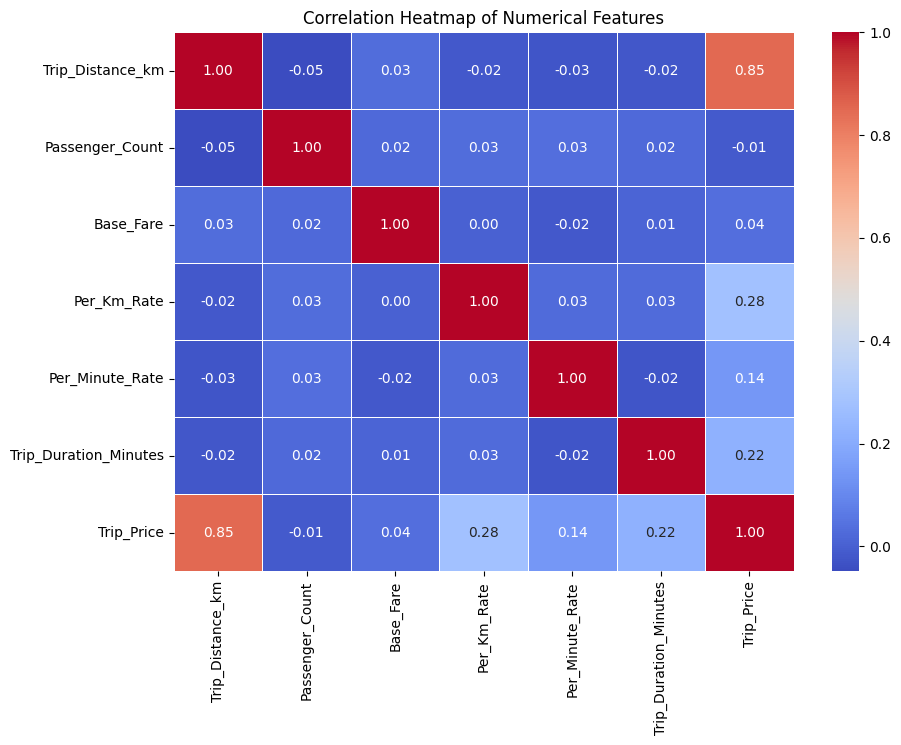

In [17]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Prepare Data for ML Algorithm

### Data Cleaning

In [18]:
# Remove rows with missing target values
taxi_prices = taxi_prices.dropna(subset=['Trip_Price']).copy()

# Check remaining missing values
print("\nMissing values after removing missing target:")
print(taxi_prices.isnull().sum())


Missing values after removing missing target:
Trip_Distance_km         50
Time_of_Day              49
Day_of_Week              46
Passenger_Count          48
Traffic_Conditions       50
Weather                  46
Base_Fare                44
Per_Km_Rate              44
Per_Minute_Rate          49
Trip_Duration_Minutes    46
Trip_Price                0
dtype: int64


### Train-Test split

In [19]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = taxi_prices.drop('Trip_Price', axis=1)
y = taxi_prices['Trip_Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Train set size: (760, 10)
Test set size: (191, 10)


## Pipeline and Handling Attributes

In [20]:
# Pipeline for numerical attributes
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numerical_cols = [
    'Trip_Distance_km',
    'Passenger_Count',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes'
]

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [21]:
# Pipeline for categorical attributes
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    'Time_of_Day',
    'Day_of_Week',
    'Traffic_Conditions',
    'Weather'
]

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [22]:
# total transformer using column transformer
from sklearn.compose import ColumnTransformer

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [23]:
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

In [24]:
print("Prepared training set shape:", X_train_prepared.shape)
print("Prepared test set shape:", X_test_prepared.shape)

Prepared training set shape: (760, 18)
Prepared test set shape: (191, 18)


In [25]:
# Verify that the preprocessing pipeline produced complete data
print("Missing values in prepared training data:",
      np.isnan(X_train_prepared.toarray()).sum()
      if hasattr(X_train_prepared, "toarray")
      else np.isnan(X_train_prepared).sum())

print("Missing values in prepared test data:",
      np.isnan(X_test_prepared.toarray()).sum()
      if hasattr(X_test_prepared, "toarray")
      else np.isnan(X_test_prepared).sum())

Missing values in prepared training data: 0
Missing values in prepared test data: 0


## Select & Train a Model

### Linear Model

In [26]:
# lets train SGDRegressor
from sklearn.linear_model import SGDRegressor

# Train the model
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd_reg.fit(X_train_prepared, y_train)


SGDRegressor(random_state=42)

In [27]:
from sklearn.metrics import root_mean_squared_error

# Predictions on training set
y_train_pred = sgd_reg.predict(X_train_prepared)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 14.40


In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Combine preprocessing and model into one pipeline
sgd_cv_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('model', SGDRegressor(
        max_iter=1000,
        tol=1e-3,
        random_state=42
    ))
])

# Cross-validation
cv_scores = cross_val_score(
    sgd_cv_pipeline,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=3
)

# Convert negative RMSE scores to positive
cv_rmse_scores = -cv_scores

print("Cross-validation RMSE scores:", cv_rmse_scores)
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.2f}")

Cross-validation RMSE scores: [14.36101502 13.11380484 16.31038617]
Mean CV RMSE: 14.60


In [29]:
# # Training and cross-validation RMSE are very close indicating that the model is not overfitting.
# We will compare with other models to determine whether SGDRegressor is underfitting.

### SVM

In [30]:
from sklearn.svm import SVR

# Train SVM with RBF kernel
svr_reg = SVR(
    kernel='rbf',
    C=1.0,
    epsilon=0.1
)

svr_reg.fit(X_train_prepared, y_train)

SVR()

In [31]:
# Predictions on training set
from sklearn.metrics import root_mean_squared_error

# Predictions on training set
y_train_pred = svr_reg.predict(X_train_prepared)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 31.08


In [32]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Combine preprocessing and SVR into one pipeline
svr_cv_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('model', SVR(
        kernel='rbf',
        C=1.0,
        epsilon=0.1
    ))
])

# Cross-validation
cv_scores = cross_val_score(
    svr_cv_pipeline,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=3
)

# Convert negative RMSE scores to positive
cv_rmse_scores = -cv_scores

print("Cross-validation RMSE scores:", cv_rmse_scores)
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.2f}")

Cross-validation RMSE scores: [36.01487733 30.58239422 31.36862027]
Mean CV RMSE: 32.66


In [33]:
# Training and cross-validation RMSE are relatively high 
# Its performance is worse than the SGDRegressor baseline.

### Decision Tree

In [34]:
# lets train a Decision Tree
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=None, random_state=42)
tree_reg.fit(X_train_prepared, y_train)

DecisionTreeRegressor(random_state=42)

In [35]:
from sklearn.metrics import root_mean_squared_error

# Evaluating on training set
y_train_pred = tree_reg.predict(X_train_prepared)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 0.00


In [36]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Combine preprocessing and Decision Tree into one pipeline
tree_cv_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('model', DecisionTreeRegressor(
        max_depth=None,
        random_state=42
    ))
])

# Cross-validation
cv_scores = cross_val_score(
    tree_cv_pipeline,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=3
)

cv_rmse_scores = -cv_scores

print("Cross-validation RMSE scores:", cv_rmse_scores)
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.2f}")

Cross-validation RMSE scores: [15.11746867 15.11605892 14.76628186]
Mean CV RMSE: 15.00


In [37]:
# The unrestricted Decision Tree achieves nearly zero training error
# but has a much higher cross-validation error, indicating severe overfitting.

In [38]:
# Fine-tuning to reduce overfitting
from sklearn.model_selection import GridSearchCV

# Pipeline containing preprocessing and Decision Tree
tree_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('model', DecisionTreeRegressor(random_state=42))
])

# Define hyperparameters for tuning
param_grid = {
    'model__max_depth': [5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

grid_search_dt = GridSearchCV(
    tree_pipeline,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Trip_Distance_km',
                                                                          'Passenger_Count',
                                                                          'Base_Fare',
                                                                          'Per_Km_Rate',
                                                                          'Per_Minute_Rate',
                                                                          'Trip_Duration_Minutes']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(str...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Time_of_Day',
                                                                          'Day_of_Week',
                                                                          'Traffic_Conditions',
                                                                          'Weather'])])),
                                       ('model',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 15, 20],
                         'model__max_features': ['sqrt', 'log2', None],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [39]:
# Best hyperparameters and score
print("Best hyperparameters:", grid_search_dt.best_params_)
print(f"Best RMSE: {-grid_search_dt.best_score_:.2f}")

Best hyperparameters: {'model__max_depth': 15, 'model__max_features': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
Best RMSE: 13.67


In [40]:
# Evaluate the best model on the training set
best_tree_reg = grid_search_dt.best_estimator_

y_train_pred = best_tree_reg.predict(X_train)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 6.88


In [41]:
# Hyperparameter tuning reduced the cross-validation RMSE from 15.00 to 13.67.
# The training RMSE also increased from 0.00 to 6.88, indicating that the tree is no longer simply memorizing the training data.
# However, the gap between training and cross-validation RMSE shows that it is still overfitting.

### Random Forest

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    random_state=42
)

rf_reg.fit(X_train_prepared, y_train)

RandomForestRegressor(random_state=42)

In [43]:
from sklearn.metrics import root_mean_squared_error

y_train_pred = rf_reg.predict(X_train_prepared)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 3.76


In [44]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

rf_cv_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('model', RandomForestRegressor(random_state=42))
])

cv_scores = cross_val_score(
    rf_cv_pipeline,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=3
)

cv_rmse_scores = -cv_scores

print("Cross-validation RMSE scores:", cv_rmse_scores)
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.2f}")

Cross-validation RMSE scores: [ 9.05466201 11.64236646 10.48488075]
Mean CV RMSE: 10.39


In [45]:
# Random Forest achievied a lower cross-validation RMSE of 10.39 compared to other models
# However, the gap between training and cross-validation RMSE indicates it is overfitting

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Pipeline containing preprocessing and Random Forest
rf_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('model', RandomForestRegressor(random_state=42))
])

# Define hyperparameters for tuning
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

Fitting 3 folds for each of 162 candidates, totalling 486 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Trip_Distance_km',
                                                                          'Passenger_Count',
                                                                          'Base_Fare',
                                                                          'Per_Km_Rate',
                                                                          'Per_Minute_Rate',
                                                                          'Trip_Duration_Minutes']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(str...
                                                                         ['Time_of_Day',
                                                                          'Day_of_Week',
                                                                          'Traffic_Conditions',
                                                                          'Weather'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20, 30],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [50, 100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [47]:
# Best hyperparameters and CV score
print("Best hyperparameters:", grid_search_rf.best_params_)
print(f"Best CV RMSE: {-grid_search_rf.best_score_:.2f}")

Best hyperparameters: {'model__max_depth': 30, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV RMSE: 17.37


In [48]:
# Evaluate the best model on the training set
best_rf_reg = grid_search_rf.best_estimator_

y_train_pred = best_rf_reg.predict(X_train)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 6.06


In [49]:
# Hyperparameter tuning resulted in worse cross-validation performance, with CV RMSE increasing from 10.39 to 17.37.
# Therefore, the original Random Forest performs better than the tuned model on unseen data, and the baseline Random Forest is preferred.

### XGBoost

In [50]:
from xgboost import XGBRegressor

# Train XGBoost
xgb_reg = XGBRegressor(
    random_state=42
)

xgb_reg.fit(X_train_prepared, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [51]:
from sklearn.metrics import root_mean_squared_error

# Predictions on training set
y_train_pred = xgb_reg.predict(X_train_prepared)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 0.33


In [52]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Combine preprocessing and XGBoost into one pipeline
xgb_cv_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('model', XGBRegressor(random_state=42))
])

# Cross-validation
cv_scores = cross_val_score(
    xgb_cv_pipeline,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=3
)

cv_rmse_scores = -cv_scores

print("Cross-validation RMSE scores:", cv_rmse_scores)
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.2f}")

Cross-validation RMSE scores: [10.57656153 16.75810624  9.62818023]
Mean CV RMSE: 12.32


In [53]:
# XGBoost achieves a low training RMSE but a substantially higher cross-validation RMSE, indicating significant overfitting.

In [54]:
# Pipeline containing preprocessing and XGBoost
xgb_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

# Define hyperparameters for tuning
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    xgb_pipeline,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Trip_Distance_km',
                                                                          'Passenger_Count',
                                                                          'Base_Fare',
                                                                          'Per_Km_Rate',
                                                                          'Per_Minute_Rate',
                                                                          'Trip_Duration_Minutes']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(str...
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.7, 0.8, 1.0],
                         'model__learning_rate': [0.01, 0.1, 0.2],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200, 300],
                         'model__subsample': [0.7, 0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [55]:
# Best hyperparameters and CV score
print("Best hyperparameters:", grid_search_xgb.best_params_)
print(f"Best CV RMSE: {-grid_search_xgb.best_score_:.2f}")

Best hyperparameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.7}
Best CV RMSE: 11.72


In [56]:
# Evaluate best model on training set
best_xgb_reg = grid_search_xgb.best_estimator_

y_train_pred = best_xgb_reg.predict(X_train)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 2.95


In [57]:
# Hyperparameter tuning improved the cross-validation RMSE from 12.32 to 11.72, but it is still overfitting.

##  Ensemble Method

In [58]:
from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import Pipeline

# Voting ensemble using the tuned models
ensemble_model = VotingRegressor(estimators=[
    ('dt', best_tree_reg),
    ('rf', best_rf_reg),
    ('xgb', best_xgb_reg)
])

# Train the ensemble
ensemble_model.fit(X_train, y_train)

VotingRegressor(estimators=[('dt',
                             Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Trip_Distance_km',
                                                                                'Passenger_Count',
                                                                                'Base_Fare',
                                                                                'Per_Km_Rate',
                                                                                'Per_Minute_Rate',
                                                                                'Trip_Duration_Minutes']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImput...
                                                           feature_weights=None,
                                                           gamma=None,
                                                           grow_policy=None,
                                                           importance_type=None,
                                                           interaction_constraints=None,
                                                           learning_rate=0.1,
                                                           max_bin=None,
                                                           max_cat_threshold=None,
                                                           max_cat_to_onehot=None,
                                                           max_delta_step=None,
                                                           max_depth=5,
                                                           max_leaves=None,
                                                           min_child_weight=None,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=100,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]))])

In [59]:
from sklearn.metrics import root_mean_squared_error

# Predictions on training set
y_train_pred = ensemble_model.predict(X_train)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

print(f"Train RMSE: {train_rmse:.2f}")

Train RMSE: 4.11


In [60]:
from sklearn.model_selection import cross_val_score

# Cross-validation
cv_scores = cross_val_score(
    ensemble_model,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=3
)

cv_rmse_scores = -cv_scores

print("Cross-validation RMSE scores:", cv_rmse_scores)
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.2f}")

Cross-validation RMSE scores: [12.25406144 10.8183909  11.87779245]
Mean CV RMSE: 11.65


In [61]:
# The Voting Regressor achieves a CV RMSE of 11.65, which is better than SGDRegressor, SVR, and the tuned Decision Tree, but it does not outperform
# the baseline Random Forest (CV RMSE: 10.39).
#We will proceed with Random Forest

## Fine-Tuning Random Forest to Reduce Overfitting

In [62]:
from sklearn.model_selection import GridSearchCV

# Final focused GridSearch for Random Forest
param_grid_rf_final = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': [None]
}

grid_search_rf_final = GridSearchCV(
    rf_pipeline,
    param_grid_rf_final,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search_rf_final.fit(X_train, y_train)

# Best hyperparameters and CV score
print("Best hyperparameters:", grid_search_rf_final.best_params_)
print(f"Best CV RMSE: {-grid_search_rf_final.best_score_:.2f}")

# Evaluate best model on training set
best_rf_final = grid_search_rf_final.best_estimator_

y_train_pred = best_rf_final.predict(X_train)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
)

print(f"Train RMSE: {train_rmse:.2f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best hyperparameters: {'model__max_depth': 15, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV RMSE: 10.27
Train RMSE: 3.73


In [63]:
# Focused hyperparameter tuning improved the Random Forest's CV RMSE from 10.39 to 10.27.
# The best configuration uses a maximum depth of 15, 100 estimators, min_samples_split=2, min_samples_leaf=1, and max_features=None.
# This configuration is selected as the final Random Forest model based on its superior cross-validation performance.

## Evaluate on test set

In [64]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Predictions on test set
y_test_pred = best_rf_final.predict(X_test)

# Evaluation metrics
rmse = root_mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f'Test RMSE: {rmse:.2f}')
print(f'Test MAE: {mae:.2f}')
print(f'Test R² Score: {r2:.2f}')

Test RMSE: 11.19
Test MAE: 6.20
Test R² Score: 0.95


In [65]:
# The final Random Forest achieves a test RMSE of 11.19, MAE of 6.20, and R² score of 0.95.
# The test RMSE is slightly higher than the cross-validation RMSE of 10.27, but remains reasonably close, indicating good generalization to unseen data.

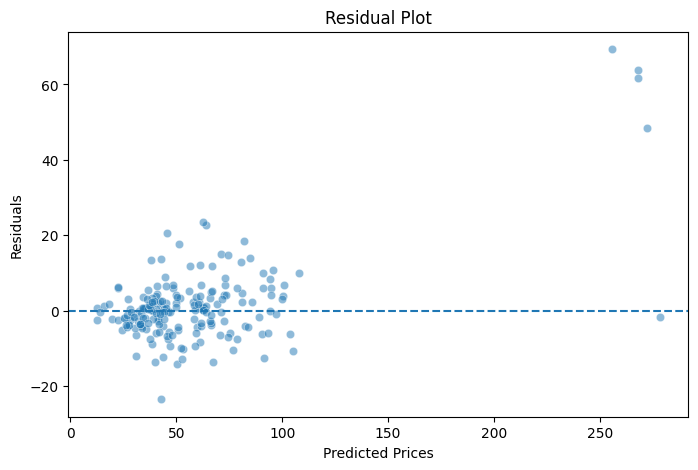

In [66]:
# Residual plot
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

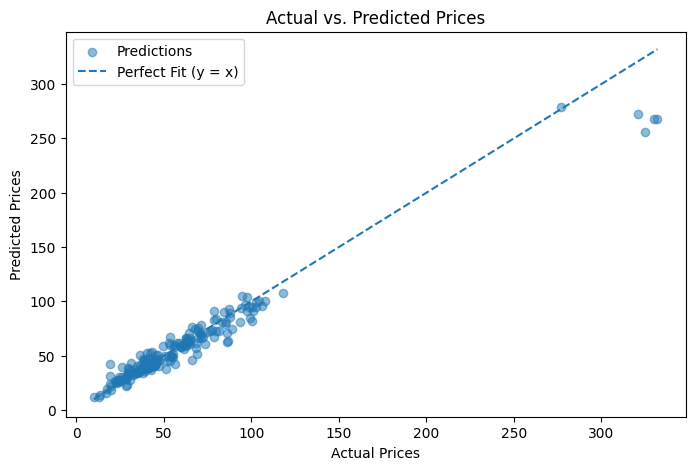

In [67]:
# Actual vs Predicted values
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5,
    label='Predictions'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    label='Perfect Fit (y = x)'
)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Prices')
plt.legend()
plt.show()

In [68]:
# Overall, the predictions are closely aligned with the actual trip prices, with most residuals centered around zero. The model performs well for the
# majority of trips, although a few high-priced trips show larger errors and are generally underestimated. Overall, the model demonstrates good
# predictive performance and generalization on the test set.